In [37]:
import pandas as pd
from datetime import datetime, timezone

ts = 1771262338996
print(datetime.fromtimestamp(ts / 1000, tz=timezone.utc))   # if ms
print(datetime.fromtimestamp(ts / 1_000_000, tz=timezone.utc))  # if us

df_raw = pd.read_parquet("datasets/telonex_raw/polymarket_book_snapshot_5_2026-02-12_89171498381181174020555224130586827134775807314573063982146628093680724415.parquet")
print(df_raw["timestamp_us"].iloc[0])
print(df_raw["local_timestamp_us"].iloc[0])
df_raw['n_ts']=df_raw['timestamp_us']//1000000

# pd.set_option('display.max_rows', 500)
# df_raw[['n_ts','ask_price_0','ask_price_1','ask_price_2','ask_price_3', 'ask_price_4', 'bid_price_0', 'bid_price_1','bid_price_2','bid_price_3','bid_price_4']].tail(100)
df = pd.read_parquet("data/telonex_book_snapshots/btc-updown-5m-1771348200.parquet")
up = df[df["token_label"] == "Up"]
pd.set_option('display.max_rows', 500)
len(up[['exchange_timestamp', 'ask_price_1','ask_price_2','ask_price_3', 'ask_price_4', 'ask_price_5', 'ask_size_5', 'mid_price','bid_price_1','bid_price_2','bid_price_3','bid_price_4','bid_price_5']])
# # Find a row with at least 3 bid levels populated
# multi_bid = up[up["bid_price_2"] > 0].iloc[0]
# print("bids:", [(multi_bid[f"bid_price_{i}"], multi_bid[f"bid_size_{i}"]) for i in range(1,6)])
# print("asks:", [(multi_bid[f"ask_price_{i}"], multi_bid[f"ask_size_{i}"]) for i in range(1,6)])

2026-02-16 17:18:58.996000+00:00
1970-01-21 12:01:02.338996+00:00
1770873540349000
1770873540377921


15379

In [9]:
df = pd.read_parquet("data/trade_events/btc-updown-5m-1771347900.parquet")
df.columns

Index(['exchange_timestamp', 'received_timestamp', 'market', 'asset_id',
       'side', 'trade_price', 'size', 'best_bid', 'best_ask', 'mid_price',
       'spread', 'hash'],
      dtype='str')

In [38]:
df = pd.read_parquet("data/telonex_book_snapshots/btc-updown-5m-1771348200.parquet")
up = df[df["token_label"] == "Up"].sort_values("exchange_timestamp")

# Time between updates in milliseconds
up["dt"] = up["exchange_timestamp"].diff()
print(up["dt"].describe())
print(f"\nUpdates per second: {1000 / up['dt'].median():.1f}")

# How often does best bid/ask actually change?
up["bid_changed"] = up["bid_price_1"].diff().abs() > 0
up["ask_changed"] = up["ask_price_1"].diff().abs() > 0
up["book_moved"]  = up["bid_changed"] | up["ask_changed"]
print(f"\nFraction of updates where top-of-book moved: {up['book_moved'].mean():.3f}")
print(f"That's {up['book_moved'].sum()} meaningful updates out of {len(up)}")

count    15378.000000
mean        19.507543
std         68.042634
min          1.000000
25%          2.000000
50%          4.000000
75%         12.000000
max       2314.000000
Name: dt, dtype: float64

Updates per second: 250.0

Fraction of updates where top-of-book moved: 0.046
That's 714 meaningful updates out of 15379


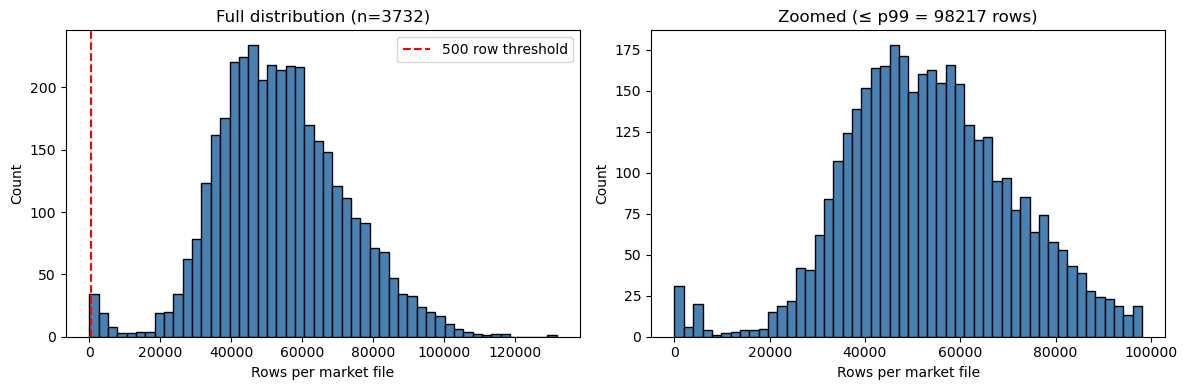

Total markets: 3732
Min: 2
p25: 41831
Median: 52911
p75: 65386
p99: 98217
Max: 131776
< 500 rows: 12


In [39]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sizes = []
for f in Path("data/telonex_book_snapshots").glob("btc-updown-5m-*.parquet"):
    df = pd.read_parquet(f, columns=["exchange_timestamp"])
    sizes.append(len(df))

sizes = np.array(sizes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution
axes[0].hist(sizes, bins=50, edgecolor="black", color="steelblue")
axes[0].axvline(500, color="red", linestyle="--", label="500 row threshold")
axes[0].set_xlabel("Rows per market file")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Full distribution (n={len(sizes)})")
axes[0].legend()

# Zoomed — drop top 1% to see the bulk
p99 = np.percentile(sizes, 99)
axes[1].hist(sizes[sizes <= p99], bins=50, edgecolor="black", color="steelblue")
axes[1].set_xlabel("Rows per market file")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Zoomed (≤ p99 = {p99:.0f} rows)")

plt.tight_layout()
plt.savefig("rows_histogram.png", dpi=150)
plt.show()

print(f"Total markets: {len(sizes)}")
print(f"Min: {sizes.min()}")
print(f"p25: {np.percentile(sizes, 25):.0f}")
print(f"Median: {np.median(sizes):.0f}")
print(f"p75: {np.percentile(sizes, 75):.0f}")
print(f"p99: {np.percentile(sizes, 99):.0f}")
print(f"Max: {sizes.max()}")
print(f"< 500 rows: {(sizes < 500).sum()}")

In [40]:
import pandas as pd
import numpy as np

df = pd.read_parquet("data/telonex_book_snapshots/btc-updown-5m-1771340100.parquet")  # one of the busiest markets
up = df[df["token_label"] == "Up"].sort_values("exchange_timestamp")
up["dt"] = up["exchange_timestamp"].diff()

print("Update interval distribution (ms):")
print(up["dt"].describe())
print(f"\np50: {up['dt'].quantile(0.5):.1f}ms")
print(f"p90: {up['dt'].quantile(0.9):.1f}ms")
print(f"p99: {up['dt'].quantile(0.99):.1f}ms")

# How many rows would survive at different resample frequencies?
for freq_ms in [10, 50, 100, 250, 500, 1000]:
    n = int(300_000 / freq_ms)
    print(f"{freq_ms}ms → {n} steps/episode")

Update interval distribution (ms):
count    53686.000000
mean         5.587956
std         10.970242
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        281.000000
Name: dt, dtype: float64

p50: 2.0ms
p90: 13.0ms
p99: 52.0ms
10ms → 30000 steps/episode
50ms → 6000 steps/episode
100ms → 3000 steps/episode
250ms → 1200 steps/episode
500ms → 600 steps/episode
1000ms → 300 steps/episode


In [43]:
import numpy as np
from polymarket_env import PolymarketEnv

env = PolymarketEnv(deterministic=True)
obs, info = env.reset()

steps = 0
while True:
    masks = info["action_masks"]
    valid = np.where(masks)[0]
    action = np.random.choice(valid)
    obs, reward, term, trunc, info = env.step(action)
    steps += 1
    if term:
        print(f"Steps: {steps}")
        print(f"Reward: {reward:.4f}")
        print(f"Final bankroll: {info['bankroll']:.2f}")
        print(f"Realized PnL: {info['realized_pnl']:.4f}")
        break

Steps: 3000
Reward: 360.5062
Final bankroll: 10360.51
Realized PnL: 360.5062


In [42]:
pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 14.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gymnasium]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
env = PolymarketEnv(deterministic=True)
obs, info = env.reset()

np.random.seed(42)
trade_log = []
steps = 0
while True:
    masks = info["action_masks"]
    valid = np.where(masks)[0]
    action = np.random.choice(valid)
    obs, reward, term, trunc, info = env.step(action)
    steps += 1
    if action != 0:
        trade_log.append({
            "step": steps,
            "action": action,
            "yes_pos": info["yes_position"],
            "no_pos": info["no_position"],
            "bankroll": info["bankroll"],
            "realized_pnl": info["realized_pnl"],
        })
    if term:
        break

import pandas as pd
print(pd.DataFrame(trade_log).to_string())

In [2]:
from pathlib import Path
from market_analysis import ResolutionStore

store  = ResolutionStore(cache_path=Path("data/resolutions.json"))
hist_slugs = sorted(p.stem for p in Path("data/telonex_book_snapshots").glob("btc-updown-5m-*.parquet"))

resolved   = {s for s in hist_slugs if store.get(s) is not None}
unresolved = [s for s in hist_slugs if store.get(s) is None]

print(f"Total markets  : {len(hist_slugs)}")
print(f"Resolved       : {len(resolved)}")
print(f"Unresolved     : {len(unresolved)}  ({100*len(unresolved)/len(hist_slugs):.1f}%)")

# Are the unresolved ones clustered at the start of the date range?
if unresolved:
    ts_vals = [int(s.split("-")[-1]) for s in unresolved]
    import pandas as pd
    print(f"\nUnresolved timestamp range:")
    print(f"  earliest: {pd.Timestamp(min(ts_vals), unit='s', tz='UTC')}")
    print(f"  latest  : {pd.Timestamp(max(ts_vals), unit='s', tz='UTC')}")
    print(f"\nResolved timestamp range:")
    res_ts = [int(s.split("-")[-1]) for s in resolved]
    print(f"  earliest: {pd.Timestamp(min(res_ts), unit='s', tz='UTC')}")
    print(f"  latest  : {pd.Timestamp(max(res_ts), unit='s', tz='UTC')}")

Total markets  : 3732
Resolved       : 3657
Unresolved     : 75  (2.0%)

Unresolved timestamp range:
  earliest: 2026-02-12 00:35:00+00:00
  latest  : 2026-02-13 18:05:00+00:00

Resolved timestamp range:
  earliest: 2026-02-12 01:40:00+00:00
  latest  : 2026-02-24 23:55:00+00:00


In [ ]:
"""
Analyze how often the eventual winning token trades below 0.50 during
its market window. This informs whether unrealized PnL shaping is viable —
if winners frequently look like losers mid-episode, Philosophy A shaping
will actively punish correct positions and push the agent to exit early.

Key questions:
  1. What fraction of winning tokens spend any time below 0.50?
  2. How deep and how long do these drawdowns go?
  3. Does this vary by time window (early vs late in the market)?
  4. Is there a relationship between entry price and final outcome?

Usage:
    python winner_price_analysis.py
"""

from pathlib import Path
import numpy as np
import pandas as pd
from market_analysis import ResolutionStore

HIST_DIR        = Path("data/telonex_book_snapshots")
RESOLUTION_PATH = Path("data/resolutions.json")
RESAMPLE_MS     = 100
MARKET_DURATION_MS = 300_000

# How many markets to sample — use all if None
SAMPLE_N = None


def load_market(path: Path, store: ResolutionStore):
    """
    Load a single market, tag each row with resolved_outcome, return
    the Up token rows only (we'll analyze winners and losers separately).
    Returns None if resolution unavailable.
    """
    slug = path.stem
    resolution = store.get(slug)
    if resolution is None:
        return None

    try:
        ts = int(slug.split("-")[-1])
    except ValueError:
        return None

    open_ms  = ts * 1000
    close_ms = open_ms + MARKET_DURATION_MS

    df = pd.read_parquet(path)
    if df.empty:
        return None

    df = df[
        (df["exchange_timestamp"] >= open_ms) &
        (df["exchange_timestamp"] <  close_ms)
    ].copy()

    # Tag each row with its resolution outcome
    df["resolved_outcome"] = df["asset_id"].map(resolution.token_outcomes)
    df = df.dropna(subset=["resolved_outcome", "mid_price"])

    # Compute seconds into market
    df["seconds_into_market"] = (df["exchange_timestamp"] - open_ms) / 1000.0
    df["slug"] = slug

    return df


def analyze_winner_prices(df: pd.DataFrame) -> dict:
    """
    For a single token's price series (already filtered to one asset_id),
    compute statistics about time spent below 0.50.
    """
    prices = df["mid_price"].values
    n      = len(prices)
    if n == 0:
        return None

    below_50     = prices < 0.50
    frac_below   = below_50.mean()
    min_price    = prices.min()
    max_drawdown = 0.50 - min_price if min_price < 0.50 else 0.0

    # Longest consecutive run below 0.50 (in rows, convert to seconds later)
    max_run = 0
    cur_run = 0
    for b in below_50:
        if b:
            cur_run += 1
            max_run  = max(max_run, cur_run)
        else:
            cur_run  = 0

    # When does the price first cross 0.50 (going up)?
    above_mask = prices >= 0.50
    first_above_idx = np.argmax(above_mask) if above_mask.any() else n
    first_above_sec = df["seconds_into_market"].iloc[first_above_idx] if first_above_idx < n else None

    # Price at market open (first row) and final 30s
    open_price  = prices[0]
    final_mask  = df["seconds_into_market"] >= 270
    final_price = df.loc[final_mask, "mid_price"].mean() if final_mask.any() else prices[-1]

    return {
        "frac_below_50":    frac_below,
        "min_price":        min_price,
        "max_drawdown":     max_drawdown,
        "max_run_below_50": max_run * (RESAMPLE_MS / 1000),  # convert to seconds
        "open_price":       open_price,
        "final_price":      final_price,
        "first_above_sec":  first_above_sec,
        "n_rows":           n,
        "ever_below_50":    bool(frac_below > 0),
    }


def main():
    store = ResolutionStore(cache_path=RESOLUTION_PATH)
    paths = sorted(HIST_DIR.glob("btc-updown-5m-*.parquet"))

    if SAMPLE_N:
        rng   = np.random.default_rng(42)
        paths = [paths[i] for i in rng.choice(len(paths), SAMPLE_N, replace=False)]

    print(f"Analyzing {len(paths)} markets...")

    winner_stats = []
    loser_stats  = []
    skipped      = 0

    for path in paths:
        df = load_market(path, store)
        if df is None:
            skipped += 1
            continue

        for asset_id, token_df in df.groupby("asset_id"):
            token_df  = token_df.sort_values("seconds_into_market").reset_index(drop=True)
            outcome   = token_df["resolved_outcome"].iloc[0]
            stats     = analyze_winner_prices(token_df)
            if stats is None:
                continue
            stats["slug"]     = token_df["slug"].iloc[0]
            stats["asset_id"] = asset_id
            stats["outcome"]  = outcome

            if outcome == 1.0:
                winner_stats.append(stats)
            else:
                loser_stats.append(stats)

    print(f"Skipped {skipped} markets (no resolution)")
    print(f"Winners: {len(winner_stats):,}  Losers: {len(loser_stats):,}\n")

    winners = pd.DataFrame(winner_stats)
    losers  = pd.DataFrame(loser_stats)

    # -----------------------------------------------------------------------
    # 1. Core question: how often do winners look like losers?
    # -----------------------------------------------------------------------
    print("=" * 60)
    print("  WINNERS: TIME SPENT BELOW 0.50")
    print("=" * 60)

    ever_below = winners["ever_below_50"].mean()
    print(f"\n  Winners that ever trade below 0.50 : {ever_below:.1%}")
    print(f"  Winners that never trade below 0.50: {1-ever_below:.1%}")

    print(f"\n  Fraction of episode below 0.50 (all winners):")
    print(winners["frac_below_50"].describe().to_string())

    # Among winners that do go below 0.50
    dipped = winners[winners["ever_below_50"]]
    print(f"\n  Among winners that dip below 0.50 ({len(dipped):,} markets):")
    print(f"    Max drawdown below 0.50:")
    print(dipped["max_drawdown"].describe().to_string())
    print(f"\n    Longest consecutive time below 0.50 (seconds):")
    print(dipped["max_run_below_50"].describe().to_string())
    print(f"\n    First time price crosses above 0.50 (seconds into market):")
    print(dipped["first_above_sec"].describe().to_string())

    # -----------------------------------------------------------------------
    # 2. Opening price distribution
    # -----------------------------------------------------------------------
    print(f"\n{'=' * 60}")
    print("  OPENING PRICE DISTRIBUTION")
    print("=" * 60)

    print(f"\n  Winners — open price:")
    print(winners["open_price"].describe().to_string())
    print(f"\n  Losers  — open price:")
    print(losers["open_price"].describe().to_string())

    # What fraction open below 0.50?
    print(f"\n  Winners opening below 0.50: {(winners['open_price'] < 0.50).mean():.1%}")
    print(f"  Losers  opening below 0.50: {(losers['open_price']  < 0.50).mean():.1%}")

    # -----------------------------------------------------------------------
    # 3. Time-bucketed analysis — does the below-0.50 pattern concentrate early?
    # -----------------------------------------------------------------------
    print(f"\n{'=' * 60}")
    print("  WHERE IN THE MARKET DO WINNERS TRADE BELOW 0.50?")
    print("=" * 60)

    # Load all winner rows and compute what fraction are below 0.50 per time bucket
    all_winner_rows = []
    for path in paths:
        df = load_market(path, store)
        if df is None:
            continue
        winner_rows = df[df["resolved_outcome"] == 1.0].copy()
        if not winner_rows.empty:
            all_winner_rows.append(winner_rows)

    if all_winner_rows:
        wr = pd.concat(all_winner_rows, ignore_index=True)
        wr["time_bucket"] = pd.cut(
            wr["seconds_into_market"],
            bins=[0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300],
            labels=["0-30s","30-60s","60-90s","90-120s","120-150s",
                    "150-180s","180-210s","210-240s","240-270s","270-300s"],
            right=False,
        )
        bucket_stats = wr.groupby("time_bucket", observed=True).agg(
            frac_below_50=("mid_price", lambda x: (x < 0.50).mean()),
            mean_price=("mid_price", "mean"),
            n_rows=("mid_price", "count"),
        ).reset_index()

        print(f"\n  {'Bucket':<12} {'Frac<0.50':>10} {'Mean price':>12} {'N rows':>10}")
        print(f"  {'-'*46}")
        for _, row in bucket_stats.iterrows():
            print(f"  {str(row['time_bucket']):<12} {row['frac_below_50']:>10.1%} "
                  f"{row['mean_price']:>12.4f} {int(row['n_rows']):>10,}")

    # -----------------------------------------------------------------------
    # 4. Implication for shaping
    # -----------------------------------------------------------------------
    print(f"\n{'=' * 60}")
    print("  SHAPING IMPLICATION SUMMARY")
    print("=" * 60)

    avg_frac_below = winners["frac_below_50"].mean()
    pct_ever_below = winners["ever_below_50"].mean()
    med_drawdown   = dipped["max_drawdown"].median() if len(dipped) else 0
    med_run        = dipped["max_run_below_50"].median() if len(dipped) else 0

    print(f"""
  {pct_ever_below:.1%} of winning tokens spend some time below 0.50.
  On average, winners spend {avg_frac_below:.1%} of the episode below 0.50.
  When they dip, the median drawdown is {med_drawdown:.3f} and the median
  consecutive time below 0.50 is {med_run:.0f}s.

  Interpretation:
  {"⚠  HIGH dip rate — unrealized PnL shaping will frequently penalize" if pct_ever_below > 0.30 else "✓  LOW dip rate — unrealized PnL shaping is relatively safe"}
  {"  correct positions. Philosophy B (realized PnL / potential-based)" if pct_ever_below > 0.30 else "  for correct positions. Philosophy A shaping is viable."}
  {"  shaping is strongly preferred." if pct_ever_below > 0.30 else ""}
""")


if __name__ == "__main__":
    main()

Analyzing 3732 markets...
Skipped 75 markets (no resolution)
Winners: 3,657  Losers: 3,657

  WINNERS: TIME SPENT BELOW 0.50

  Winners that ever trade below 0.50 : 99.7%
  Winners that never trade below 0.50: 0.3%

  Fraction of episode below 0.50 (all winners):
count    3657.000000
mean        0.281390
std         0.260290
min         0.000000
25%         0.053564
50%         0.202728
75%         0.457922
max         1.000000

  Among winners that dip below 0.50 (3,647 markets):
    Max drawdown below 0.50:
count    3647.000000
mean        0.170627
std         0.141269
min         0.000500
25%         0.045000
50%         0.145000
75%         0.275000
max         0.499500

    Longest consecutive time below 0.50 (seconds):
count    3647.000000
mean      561.443735
std       682.482569
min         0.400000
25%        66.400000
50%       277.600000
75%       816.700000
max      4712.200000

    First time price crosses above 0.50 (seconds into market):
count    3645.000000
mean       1

In [1]:
"""
Analyze how often the eventual winning token trades below 0.50 during
its market window.

Memory strategy: accumulate sufficient statistics per market, never
concat full datasets. Peak RAM = one market's parquet at a time (~2MB).
"""

from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
from market_analysis import ResolutionStore

HIST_DIR           = Path("data/telonex_book_snapshots")
RESOLUTION_PATH    = Path("data/resolutions.json")
MARKET_DURATION_MS = 300_000
RESAMPLE_MS        = 100
TIME_BINS          = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300]
TIME_LABELS        = ["0-30s","30-60s","60-90s","90-120s","120-150s",
                      "150-180s","180-210s","210-240s","240-270s","270-300s"]


def process_token(prices: np.ndarray, seconds: np.ndarray, outcome: float) -> dict:
    """
    Compute all statistics for one token from its price array.
    Pure numpy — no pandas, no Python loops except the RLE which operates
    on a diff array rather than iterating rows.
    """
    below = prices < 0.50
    n     = len(prices)

    frac_below   = below.mean()
    min_price    = prices.min()
    open_price   = prices[0]

    final_mask   = seconds >= 270
    final_price  = prices[final_mask].mean() if final_mask.any() else prices[-1]

    # First index where price >= 0.50
    above_idx       = np.argmax(~below)
    first_above_sec = seconds[above_idx] if not below[above_idx] else np.nan

    # Longest consecutive run below 0.50 via RLE on diff
    # Pad with False on both ends so runs at edges are correctly terminated
    padded   = np.concatenate([[False], below, [False]])
    switches = np.diff(padded.astype(np.int8))
    starts   = np.where(switches == 1)[0]
    ends     = np.where(switches == -1)[0]
    run_lens = ends - starts  # length of each below-50 run in rows
    max_run_s = (run_lens.max() * RESAMPLE_MS / 1000.0) if len(run_lens) else 0.0

    return {
        "outcome":        outcome,
        "frac_below_50":  float(frac_below),
        "ever_below_50":  bool(frac_below > 0),
        "min_price":      float(min_price),
        "max_drawdown":   max(0.0, 0.50 - float(min_price)),
        "open_price":     float(open_price),
        "final_price":    float(final_price),
        "first_above_sec": float(first_above_sec),
        "max_run_s":      float(max_run_s),
        "n_rows":         n,
    }


def main():
    store = ResolutionStore(cache_path=RESOLUTION_PATH)
    paths = sorted(HIST_DIR.glob("btc-updown-5m-*.parquet"))

    # Pre-filter to resolved slugs only
    resolved_paths = []
    slug_outcomes  = {}
    for path in paths:
        res = store.get(path.stem)
        if res is not None:
            resolved_paths.append(path)
            slug_outcomes[path.stem] = res.token_outcomes

    print(f"Resolved: {len(resolved_paths):,} / {len(paths):,} markets")

    # Accumulators — lists of per-token stat dicts (small, ~2 floats per market)
    token_stats = []

    # Time-bucket accumulators: {bucket_idx: [below_count, total_count, price_sum]}
    winner_buckets = defaultdict(lambda: np.zeros(3))

    skipped = 0
    for i, path in enumerate(resolved_paths):
        slug    = path.stem
        outcomes = slug_outcomes[slug]

        try:
            open_ms = int(slug.split("-")[-1]) * 1000
        except ValueError:
            skipped += 1
            continue

        try:
            df = pd.read_parquet(path, columns=["exchange_timestamp", "asset_id", "mid_price"])
        except Exception:
            skipped += 1
            continue

        if df.empty:
            skipped += 1
            continue

        # Window filter
        close_ms = open_ms + MARKET_DURATION_MS
        df = df[(df["exchange_timestamp"] >= open_ms) &
                (df["exchange_timestamp"] <  close_ms)]
        if df.empty:
            skipped += 1
            continue

        df["seconds"] = (df["exchange_timestamp"] - open_ms) / 1000.0
        df["outcome"] = df["asset_id"].map(outcomes)
        df = df.dropna(subset=["outcome", "mid_price"])

        # Process each token independently — no groupby, just boolean index
        for asset_id, out_val in outcomes.items():
            mask   = df["asset_id"] == asset_id
            subset = df[mask].sort_values("seconds")
            if len(subset) < 5:
                continue

            prices  = subset["mid_price"].to_numpy(dtype=np.float32)
            seconds = subset["seconds"].to_numpy(dtype=np.float32)

            stats = process_token(prices, seconds, out_val)
            stats["slug"] = slug
            token_stats.append(stats)

            # Accumulate time-bucket stats for winners only
            if out_val == 1.0:
                bucket_idx = np.searchsorted(TIME_BINS[1:], seconds, side="right")
                bucket_idx = np.clip(bucket_idx, 0, len(TIME_LABELS) - 1)
                below      = prices < 0.50
                for b in range(len(TIME_LABELS)):
                    bmask = bucket_idx == b
                    if bmask.any():
                        winner_buckets[b][0] += below[bmask].sum()   # below count
                        winner_buckets[b][1] += bmask.sum()           # total count
                        winner_buckets[b][2] += prices[bmask].sum()   # price sum

        if (i + 1) % 500 == 0:
            print(f"  Processed {i+1:,}/{len(resolved_paths):,}...")

    print(f"Done. Skipped {skipped} markets.\n")

    # -----------------------------------------------------------------------
    # Build summary DataFrames from accumulators
    # -----------------------------------------------------------------------
    stats_df = pd.DataFrame(token_stats)
    winners  = stats_df[stats_df["outcome"] == 1.0]
    losers   = stats_df[stats_df["outcome"] == 0.0]
    dipped   = winners[winners["ever_below_50"]]

    # -----------------------------------------------------------------------
    # Report
    # -----------------------------------------------------------------------
    print("=" * 60)
    print("  WINNERS: TIME SPENT BELOW 0.50")
    print("=" * 60)

    ever_pct = winners["ever_below_50"].mean()
    print(f"\n  Ever below 0.50 : {ever_pct:.1%}  ({winners['ever_below_50'].sum():,} of {len(winners):,})")
    print(f"  Never below 0.50: {1-ever_pct:.1%}")
    print(f"\n  Fraction of episode below 0.50 (all winners):")
    print(winners["frac_below_50"].describe().to_string())

    if len(dipped):
        print(f"\n  Among winners that dip ({len(dipped):,} markets):")
        print(f"\n    Max drawdown below 0.50:")
        print(dipped["max_drawdown"].describe().to_string())
        print(f"\n    Longest consecutive time below 0.50 (seconds):")
        print(dipped["max_run_s"].describe().to_string())
        print(f"\n    First cross above 0.50 (seconds into market):")
        print(dipped["first_above_sec"].describe().to_string())

    print(f"\n{'='*60}")
    print("  OPENING PRICE DISTRIBUTION")
    print(f"{'='*60}")
    print(f"\n  Winners open price:"); print(winners["open_price"].describe().to_string())
    print(f"\n  Losers  open price:"); print(losers["open_price"].describe().to_string())
    print(f"\n  Winners opening below 0.50: {(winners['open_price'] < 0.50).mean():.1%}")
    print(f"  Losers  opening below 0.50: {(losers['open_price']  < 0.50).mean():.1%}")

    print(f"\n{'='*60}")
    print("  WHERE IN THE MARKET DO WINNERS TRADE BELOW 0.50?")
    print(f"{'='*60}")
    print(f"\n  {'Bucket':<12} {'Frac<0.50':>10} {'Mean price':>12} {'N rows':>10}")
    print(f"  {'-'*46}")
    for b, label in enumerate(TIME_LABELS):
        below_n, total_n, price_sum = winner_buckets[b]
        if total_n == 0:
            continue
        print(f"  {label:<12} {below_n/total_n:>10.1%} "
              f"{price_sum/total_n:>12.4f} {int(total_n):>10,}")

    print(f"\n{'='*60}")
    print("  SHAPING IMPLICATION SUMMARY")
    print(f"{'='*60}")
    avg_frac = winners["frac_below_50"].mean()
    med_dd   = dipped["max_drawdown"].median()  if len(dipped) else 0.0
    med_run  = dipped["max_run_s"].median()     if len(dipped) else 0.0
    verdict  = "HIGH" if ever_pct > 0.30 else "LOW"
    rec      = ("Philosophy B (potential-based) shaping strongly preferred."
                if ever_pct > 0.30 else
                "Philosophy A (unrealized PnL) shaping is viable.")
    print(f"""
  {ever_pct:.1%} of winning tokens spend some time below 0.50.
  On average, winners spend {avg_frac:.1%} of the episode below 0.50.
  Median drawdown depth  : {med_dd:.3f}
  Median time below 0.50 : {med_run:.0f}s

  {verdict} dip rate — {rec}
""")


if __name__ == "__main__":
    main()

Resolved: 3,657 / 3,732 markets
  Processed 500/3,657...
  Processed 1,000/3,657...
  Processed 1,500/3,657...
  Processed 2,000/3,657...
  Processed 2,500/3,657...
  Processed 3,000/3,657...
  Processed 3,500/3,657...
Done. Skipped 0 markets.

  WINNERS: TIME SPENT BELOW 0.50

  Ever below 0.50 : 99.7%  (3,647 of 3,657)
  Never below 0.50: 0.3%

  Fraction of episode below 0.50 (all winners):
count    3657.000000
mean        0.281390
std         0.260290
min         0.000000
25%         0.053564
50%         0.202728
75%         0.457922
max         1.000000

  Among winners that dip (3,647 markets):

    Max drawdown below 0.50:
count    3647.000000
mean        0.170627
std         0.141269
min         0.000500
25%         0.045000
50%         0.145000
75%         0.275000
max         0.499500

    Longest consecutive time below 0.50 (seconds):
count    3647.000000
mean      561.443735
std       682.482569
min         0.400000
25%        66.400000
50%       277.600000
75%       816.70

In [1]:
import pandas as pd
from pathlib import Path

f = next(Path("data/telonex_100ms").glob("*.parquet"))
df = pd.read_parquet(f)
print(df.columns.tolist())

['exchange_timestamp', 'token_label', 'asset_id', 'mid_price', 'spread', 'book_imbalance', 'bid_price_1', 'bid_size_1', 'bid_price_2', 'bid_size_2', 'bid_price_3', 'bid_size_3', 'bid_price_4', 'bid_size_4', 'bid_price_5', 'bid_size_5', 'ask_price_1', 'ask_size_1', 'ask_price_2', 'ask_size_2', 'ask_price_3', 'ask_size_3', 'ask_price_4', 'ask_size_4', 'ask_price_5', 'ask_size_5', 'staleness_ms', 'resolved_value']


In [2]:
import numpy as np
from pathlib import Path
from polymarket_env import PolymarketEnv

env = PolymarketEnv(book_dir="data/telonex_100ms",
                    btc_path="data/btc_quotes/btcusdt_quotes.parquet",
                    deterministic=True)

rewards = []
for _ in range(200):
    obs, info = env.reset()
    total = 0.0
    while True:
        masks = info["action_masks"]
        action = np.random.choice(np.where(masks)[0])
        obs, reward, term, trunc, info = env.step(action)
        total += reward
        if term or trunc:
            break
    rewards.append(total)

print(f"Random agent over 200 episodes:")
print(f"  Mean:   ${np.mean(rewards):.2f}")
print(f"  Std:    ${np.std(rewards):.2f}")
print(f"  Median: ${np.median(rewards):.2f}")
print(f"  Min:    ${np.min(rewards):.2f}")
print(f"  Max:    ${np.max(rewards):.2f}")

Random agent over 200 episodes:
  Mean:   $306.02
  Std:    $917.60
  Median: $92.96
  Min:    $-1108.92
  Max:    $5277.11


In [5]:
# On System A — identify the last 2 days of data
from pathlib import Path
import numpy as np

files = sorted(Path("data/telonex_100ms").glob("*.parquet"))
# Timestamps are in filenames — last element after splitting on -
timestamps = [(f, int(f.stem.split("-")[-1])) for f in files]
timestamps.sort(key=lambda x: x[1])

cutoff = timestamps[-1][1] - (2 * 24 * 3600)  # 2 days before last market
test  = [f for f, ts in timestamps if ts >= cutoff]
train = [f for f, ts in timestamps if ts <  cutoff]
print(f"Train: {len(train)} markets")
print(f"Test:  {len(test)} markets")
print(f"Test window: {test[0].stem} to {test[-1].stem}")

Train: 3731 markets
Test:  548 markets
Test window: btc-updown-5m-1771977300 to btc-updown-5m-1772150100


In [6]:
import numpy as np
from pathlib import Path
from polymarket_env import PolymarketEnv

env = PolymarketEnv(book_dir="data/telonex_100ms",
                    btc_path="data/btc_quotes/btcusdt_quotes.parquet",
                    deterministic=True)

rewards = []
for _ in range(200):
    obs, info = env.reset()
    total = 0.0
    while True:
        masks = info["action_masks"]
        action = np.random.choice(np.where(masks)[0])
        obs, reward, term, trunc, info = env.step(action)
        total += reward
        if term or trunc:
            break
    rewards.append(total)

print(f"Random agent over 200 episodes:")
print(f"  Mean:   ${np.mean(rewards):.2f}")
print(f"  Std:    ${np.std(rewards):.2f}")
print(f"  Median: ${np.median(rewards):.2f}")
print(f"  Min:    ${np.min(rewards):.2f}")
print(f"  Max:    ${np.max(rewards):.2f}")

Random agent over 200 episodes:
  Mean:   $292.54
  Std:    $1301.06
  Median: $-29.06
  Min:    $-1094.69
  Max:    $9161.10


In [7]:
def _robust_mid(yes_row, no_row=None) -> tuple[float, float]:
    yes_mid = _book_mid(yes_row)
    no_mid  = _book_mid(no_row)
    
    # Sanity check: if one side has a healthy book, anchor the other to complement
    yes_healthy = _book_is_healthy(yes_row)
    no_healthy  = _book_is_healthy(no_row)
    
    if yes_healthy and not no_healthy:
        no_mid = 1.0 - yes_mid
    elif no_healthy and not yes_healthy:
        yes_mid = 1.0 - no_mid
    elif yes_healthy and no_healthy:
        # Both healthy — use average of direct mid and complement as sanity check
        # If they disagree by more than threshold, trust the healthier book
        pass  
    
    return yes_mid, no_mid

In [8]:
"""
analyze_spreads.py — Spread and book health distribution analysis.

Run from project root:
    python analyze_spreads.py
    python analyze_spreads.py --data-dir data/telonex_100ms --sample 200
"""

import argparse
import random
import numpy as np
import pandas as pd
from pathlib import Path

parser = argparse.ArgumentParser()
parser.add_argument('--data-dir', default='data/telonex_100ms')
parser.add_argument('--sample',   type=int, default=100)
parser.add_argument('--seed',     type=int, default=42)
args = parser.parse_args()

random.seed(args.seed)
np.random.seed(args.seed)

files = sorted(Path(args.data_dir).glob('*.parquet'))
print(f"Total files: {len(files)}")
if not files:
    raise SystemExit("No parquet files found. Check --data-dir.")

sample = random.sample(files, min(args.sample, len(files)))
print(f"Sampling {len(sample)} markets...\n")

# Accumulate raw observations
all_spreads   = []
all_bid_sizes = []
all_ask_sizes = []
n_both = n_bid_only = n_ask_only = n_neither = 0

# Per-market: track fraction of bars that are one-sided
market_onesided_fracs = []

for f in sample:
    df = pd.read_parquet(f)
    for label in ['Up', 'Down']:
        tok = df[df['token_label'] == label]
        if tok.empty:
            continue

        bid_p = tok['bid_price_1'].fillna(0)
        ask_p = tok['ask_price_1'].fillna(0)
        bid_s = tok['bid_size_1'].fillna(0)
        ask_s = tok['ask_size_1'].fillna(0)

        has_bid = (bid_p > 0) & (bid_s > 0)
        has_ask = (ask_p > 0) & (ask_s > 0)

        both    = (has_bid & has_ask)
        bid_only = (has_bid & ~has_ask)
        ask_only = (~has_bid & has_ask)
        neither = (~has_bid & ~has_ask)

        n_both     += int(both.sum())
        n_bid_only += int(bid_only.sum())
        n_ask_only += int(ask_only.sum())
        n_neither  += int(neither.sum())

        # Spreads on two-sided bars
        spread = (ask_p[both] - bid_p[both])
        all_spreads.extend(spread.tolist())

        # Sizes on non-zero levels
        all_bid_sizes.extend(bid_s[has_bid].tolist())
        all_ask_sizes.extend(ask_s[has_ask].tolist())

        # Per-token one-sided fraction
        n_total = len(tok)
        if n_total > 0:
            market_onesided_fracs.append((bid_only.sum() + ask_only.sum()) / n_total)

all_spreads   = np.array(all_spreads)
all_bid_sizes = np.array(all_bid_sizes)
all_ask_sizes = np.array(all_ask_sizes)
market_onesided_fracs = np.array(market_onesided_fracs)

total_bars = n_both + n_bid_only + n_ask_only + n_neither

print("=" * 60)
print("BOOK SIDEDNESS (per 100ms bar)")
print("=" * 60)
print(f"  Both sided:  {n_both:9,}  ({100*n_both/total_bars:5.1f}%)")
print(f"  Bid only:    {n_bid_only:9,}  ({100*n_bid_only/total_bars:5.1f}%)")
print(f"  Ask only:    {n_ask_only:9,}  ({100*n_ask_only/total_bars:5.1f}%)")
print(f"  Neither:     {n_neither:9,}  ({100*n_neither/total_bars:5.1f}%)")
print(f"  Total bars:  {total_bars:9,}")

print()
print("=" * 60)
print("ONE-SIDED FRACTION PER TOKEN (distribution across tokens)")
print("=" * 60)
for p in [0, 10, 25, 50, 75, 90, 95, 99, 100]:
    print(f"  p{p:3d}: {np.percentile(market_onesided_fracs, p)*100:5.1f}% of bars one-sided")

print()
print("=" * 60)
print("SPREAD DISTRIBUTION (two-sided bars only)")
print("=" * 60)
print(f"  Observations: {len(all_spreads):,}")
# Remove crossed/negative spreads
valid = all_spreads[all_spreads >= 0]
invalid = len(all_spreads) - len(valid)
if invalid:
    print(f"  Crossed books (spread < 0): {invalid:,} ({100*invalid/len(all_spreads):.2f}%)")
print(f"  Valid spreads: {len(valid):,}")
for p in [5, 10, 25, 50, 75, 90, 95, 99, 99.9]:
    print(f"  p{p:5.1f}: {np.percentile(valid, p):.4f}  ({np.percentile(valid, p)*100:.2f} cents)")
print(f"  mean:  {valid.mean():.4f}  ({valid.mean()*100:.2f} cents)")
print(f"  max:   {valid.max():.4f}  ({valid.max()*100:.2f} cents)")

# Spread buckets
print()
print("  Spread buckets:")
buckets = [0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 1.01]
labels  = ['<1c', '1-2c', '2-5c', '5-10c', '10-20c', '20-50c', '>50c']
counts  = np.histogram(valid, bins=[0]+buckets)[0]
for label, count in zip(labels, counts):
    print(f"    {label:8s}: {count:8,}  ({100*count/len(valid):5.1f}%)")

print()
print("=" * 60)
print("BID SIZE DISTRIBUTION (non-zero bid_size_1, in $)")
print("=" * 60)
for p in [5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:3d}: ${np.percentile(all_bid_sizes, p):8.2f}")
print(f"  mean: ${all_bid_sizes.mean():8.2f}")

print()
print("=" * 60)
print("ASK SIZE DISTRIBUTION (non-zero ask_size_1, in $)")
print("=" * 60)
for p in [5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:3d}: ${np.percentile(all_ask_sizes, p):8.2f}")
print(f"  mean: ${all_ask_sizes.mean():8.2f}")

# Suggested thresholds
print()
print("=" * 60)
print("SUGGESTED THRESHOLDS")
print("=" * 60)
spread_90 = np.percentile(valid, 90)
spread_95 = np.percentile(valid, 95)
size_25   = np.percentile(all_bid_sizes, 25)
size_10   = np.percentile(all_bid_sizes, 10)
print(f"  MAX_SPREAD for 'healthy' book:  {spread_90:.3f} (p90) or {spread_95:.3f} (p95)")
print(f"  MIN_SIZE for 'healthy' book:    ${size_25:.2f} (p25 bid size) or ${size_10:.2f} (p10)")
print()
print("  Interpretation:")
print(f"  - A spread > {spread_90:.2f} suggests a thin/manipulable book")
print(f"  - A top-of-book size < ${size_25:.2f} suggests a token with no real liquidity")

usage: ipykernel_launcher.py [-h] [--data-dir DATA_DIR] [--sample SAMPLE]
                             [--seed SEED]
ipykernel_launcher.py: error: unrecognized arguments: -f /home/jovyan/.local/share/jupyter/runtime/kernel-ac82c3f3-e23c-4334-8dda-94c389c5ece6.json


SystemExit: 2

/opt/conda/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [1]:
import pandas as pd
from pathlib import Path

files = sorted(Path("data/trade_events").glob("*.parquet"))
print(f"Found {len(files)} files")
print(files[:5])

df = pd.read_parquet(files[0])
print(df.dtypes)
print(df.head(3).to_string())

Found 1405 files
[PosixPath('data/trade_events/btc-updown-5m-1771346400.parquet'), PosixPath('data/trade_events/btc-updown-5m-1771346700.parquet'), PosixPath('data/trade_events/btc-updown-5m-1771347000.parquet'), PosixPath('data/trade_events/btc-updown-5m-1771347300.parquet'), PosixPath('data/trade_events/btc-updown-5m-1771347600.parquet')]
exchange_timestamp      int64
received_timestamp      int64
market                    str
asset_id                  str
side                      str
trade_price           float64
size                  float64
best_bid              float64
best_ask              float64
mid_price             float64
spread                float64
hash                      str
dtype: object
   exchange_timestamp  received_timestamp                                                              market                                                                       asset_id  side  trade_price      size  best_bid  best_ask  mid_price  spread                           

In [6]:
import pandas as pd
from pathlib import Path

df = pd.read_parquet(Path("data/trade_events/btc-updown-5m-1771347000.parquet"))

print("Hash lengths:", df["hash"].str.len().value_counts())
print("\nSample hashes:")
print(df["hash"].head(5).tolist())

# Also check the timestamp delta
df["latency_ms"] = df["received_timestamp"] - df["exchange_timestamp"]
print(f"\nWS delivery latency (exchange→received): "
      f"median={df['latency_ms'].median():.0f}ms  "
      f"max={df['latency_ms'].max():.0f}ms")

Hash lengths: hash
40    154556
Name: count, dtype: int64

Sample hashes:
['858e5d3f72d9c183575ec548d9793a6e1fc692d6', '5618e71364d8d1d92e76f36b19d96e580b5160a0', '649290dec99849716c1d415c8f80a01b272e9b8f', '163003df8b42c5545a01b0310bbbacdb224806b8', '010d2cb2e2ef11119fc621fecf18b399911f7a31']

WS delivery latency (exchange→received): median=27ms  max=924ms


In [4]:
import pandas as pd
from pathlib import Path
from datetime import datetime, timezone

df = pd.read_parquet(Path("data/trade_events/btc-updown-5m-1771346700.parquet"))

# Inspect raw values
print("exchange_timestamp sample:", df["exchange_timestamp"].head(3).tolist())
print("received_timestamp sample:", df["received_timestamp"].head(3).tolist())

# Try interpreting as ms since epoch
for col in ["exchange_timestamp", "received_timestamp"]:
    val = df[col].iloc[0]
    as_ms  = datetime.fromtimestamp(val / 1000, tz=timezone.utc)
    as_sec = datetime.fromtimestamp(val, tz=timezone.utc)
    as_us  = datetime.fromtimestamp(val / 1_000_000, tz=timezone.utc)
    print(f"\n{col} = {val}")
    print(f"  as seconds:      {as_sec}")
    print(f"  as milliseconds: {as_ms}")
    print(f"  as microseconds: {as_us}")

exchange_timestamp sample: [1771346768668, 1771346768668, 1771346768671]
received_timestamp sample: [1771346768708, 1771346768708, 1771346768708]


ValueError: year 58101 is out of range

In [7]:
import pandas as pd
from pathlib import Path

# Check a book snapshot file for the same market
book_files = sorted(Path("data/telonex_15m_100ms").glob("btc-updown-5m-*.parquet"))
if book_files:
    df = pd.read_parquet(book_files[0])
    print(df.dtypes)
    print(df.head(2).to_string())

In [8]:
import pandas as pd
from pathlib import Path

df = pd.read_parquet(sorted(Path("data/trade_events").glob("*.parquet"))[0])

sample_hash = df["hash"].iloc[0]
print(f"Hash: {sample_hash}")
print(f"Length: {len(sample_hash)}")

# If it's an ETH tx hash without 0x prefix, it would be 64 chars
# 40 chars = looks like it could be a truncated hash or CLOB-internal ID
# Cross-check: does the same hash appear in multiple rows?
print(f"\nHash value counts (top 10):")
print(df["hash"].value_counts().head(10))

# Also check if complementary Yes/No legs share a hash
print(f"\nRows sharing a hash:")
dupes = df[df.duplicated("hash", keep=False)].sort_values("hash")
print(dupes[["exchange_timestamp", "asset_id", "side", "trade_price", "size", "hash"]].head(8).to_string())

Hash: de260e5db34814789f231c2e228b6f14a4f3d265
Length: 40

Hash value counts (top 10):
hash
feef9ad235dd54354e013b4c9cf5a600d3508c64    101
c3ea345b9c03c105e7078ffb0703a7eeb20ecf2f    101
2999c6ff2274a83b864789628f4a051b2944da4b     99
df49cbf19ce0fd79fc2eabbd235cb076950faaec     99
f1a56082da70bb02bc0363aab1cfee66f474ca0a     79
0b7fa6cf098f851e1d0246bd00011a7ae452aee0     79
a3abd4f207d61e216833563f015d6d588f9ad3b7     20
4fc2db4700c64b34a43ef2aaf3705d156da2f9ad     20
3b7ceedf4e12a14ed3ed2c2778a8d9696318d2f4     20
e428b75794200c2980bb654a6bba89d413565984     20
Name: count, dtype: int64

Rows sharing a hash:
      exchange_timestamp                                                                       asset_id  side  trade_price    size                                      hash
6095       1771346209327  69498942779254888910711294574889979045774995037173242112935759571032852040726  SELL         0.94   93.61  001641a6250cc365763aadc39ad75b410d5b824a
6096       1771346209327  69498942

In [11]:
!pip install web3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.5/587.5 kB 62.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 42.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.1/802.1 kB 50.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26/26 [web3]2m24/26 [eth-account]]


In [12]:
import requests

CTF_EXCHANGE = "0x4bFb41d5B3570DeFd03C39a9A4D8dE6Bd8B8982E"
ETHERSCAN_API = "https://api.etherscan.io/v2/api"

with open("config.json") as f:
    import json
    ETHERSCAN_KEY = json.load(f)["etherscan"]["api_key"]

# Fetch the verified ABI
r = requests.get(ETHERSCAN_API, params={
    "chainid": 137,
    "module":  "contract",
    "action":  "getabi",
    "address": CTF_EXCHANGE,
    "apikey":  ETHERSCAN_KEY,
})
abi = json.loads(r.json()["result"])

# Compute 4-byte selectors for all functions
from web3 import Web3
for item in abi:
    if item.get("type") != "function":
        continue
    name   = item["name"]
    inputs = ",".join(i["type"] for i in item.get("inputs", []))
    sig    = f"{name}({inputs})"
    sel    = Web3.keccak(text=sig).hex()[:10]
    print(f"{sel}  {sig}")

7048027520  addAdmin(address)
9870d7fe5d  addOperator(address)
429b62e5e7  admins(address)
3089c27d0f  cancelOrder(tuple)
b3cc12db07  cancelOrders(tuple[])
f698da2508  domainSeparator()
46e5649155  fillOrder(tuple,uint256)
d4a6dea231  fillOrders(tuple[],uint256[])
5c1548fb1a  getCollateral()
a10f3dcea5  getComplement(uint256)
d7fb272f04  getConditionId(uint256)
3b521d789d  getCtf()
4a2a11f56f  getMaxFeeRate()
46423aa712  getOrderStatus(bytes32)
06b9d691f6  getPolyProxyFactoryImplementation()
edef7d8eef  getPolyProxyWalletAddress(address)
b28c51c006  getProxyFactory()
a287bdf171  getSafeAddress(address)
75d7370a78  getSafeFactory()
e03ac3d08d  getSafeFactoryImplementation()
abace27a66  hashOrder(tuple)
627cdcb955  incrementNonce()
24d7806c82  isAdmin(address)
6d70f7aed2  isOperator(address)
0647ee2018  isValidNonce(address,uint256)
37e4ec31c0  matchOrders(tuple,tuple[],uint256,uint256[])
7ecebe00bc  nonces(address)
bc197c819b  onERC1155BatchReceived(address,address,uint256[],uint256[],b

In [13]:
"""
batch_cadence.py

Measures the interval between consecutive matchOrders settlements on the
CTF Exchange by querying OrdersMatched event logs directly from Etherscan.

This gives the operator's batch submission cadence — which is the actual
race window for a nonce exploit. No trade matching heuristic needed.

Usage:
    python batch_cadence.py
    python batch_cadence.py --days 7 --out data/batch_cadence.parquet

Requires config.json with:
    {"etherscan": {"api_key": "YOUR_KEY"}}
"""

import argparse
import json
import time
from datetime import datetime, timezone, timedelta
from pathlib import Path

import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from web3 import Web3

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------

CTF_EXCHANGE  = "0x4bFb41d5B3570DeFd03C39a9A4D8dE6Bd8B8982E"
ETHERSCAN_API = "https://api.etherscan.io/v2/api"
POLYGON_RPC   = "https://polygon-rpc.com"

# OrdersMatched event topic — keccak256 of the signature
# Signature from ABI: OrdersMatched(bytes32,address,uint256,uint256,uint256,uint256)
# Precomputed: Web3.keccak(text="OrdersMatched(bytes32,address,uint256,uint256,uint256,uint256)").hex()
ORDERS_MATCHED_TOPIC = "0x" + Web3.keccak(
    text="OrdersMatched(bytes32,address,uint256,uint256,uint256,uint256)"
).hex()

# ---------------------------------------------------------------------------
# Args
# ---------------------------------------------------------------------------

parser = argparse.ArgumentParser()
parser.add_argument("--days", type=int, default=3,
                    help="How many days of history to pull (default: 3)")
parser.add_argument("--out",  default="data/batch_cadence.parquet")
args = parser.parse_args()

# ---------------------------------------------------------------------------
# Auth
# ---------------------------------------------------------------------------

with open("config.json") as f:
    config = json.load(f)

ETHERSCAN_KEY = config["etherscan"]["api_key"]

# ---------------------------------------------------------------------------
# HTTP session with retries
# ---------------------------------------------------------------------------

def make_session() -> requests.Session:
    s = requests.Session()
    s.mount("https://", HTTPAdapter(max_retries=Retry(
        total=5,
        backoff_factor=1.0,
        status_forcelist=[429, 500, 502, 503, 504],
    )))
    return s

SESSION = make_session()
w3 = Web3(Web3.HTTPProvider(POLYGON_RPC))

# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def ts_to_block(ts_s: int) -> int:
    r = SESSION.get(ETHERSCAN_API, params={
        "chainid":   137,
        "module":    "block",
        "action":    "getblocknobytime",
        "timestamp": ts_s,
        "closest":   "before",
        "apikey":    ETHERSCAN_KEY,
    }, timeout=30)
    result = r.json().get("result")
    return int(result)


def fetch_logs(from_block: int, to_block: int) -> list[dict]:
    """
    Fetch all OrdersMatched event logs for the CTF Exchange in a block range.
    Etherscan log queries max out at 1000 results — paginate if needed.
    """
    logs = []
    page = 1

    while True:
        r = SESSION.get(ETHERSCAN_API, params={
            "chainid":   137,
            "module":    "logs",
            "action":    "getLogs",
            "address":   CTF_EXCHANGE,
            "topic0":    ORDERS_MATCHED_TOPIC,
            "fromBlock": from_block,
            "toBlock":   to_block,
            "page":      page,
            "offset":    1000,
            "apikey":    ETHERSCAN_KEY,
        }, timeout=30)

        data = r.json()
        result = data.get("result", [])

        if not isinstance(result, list) or not result:
            break

        logs.extend(result)

        if len(result) < 1000:
            break  # last page

        page += 1
        time.sleep(0.2)

    return logs

# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def main():
    out_path = Path(args.out)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    now       = int(datetime.now(timezone.utc).timestamp())
    start_ts  = now - args.days * 86400

    print(f"Querying OrdersMatched events for last {args.days} days...")
    print(f"CTF Exchange: {CTF_EXCHANGE}")
    print(f"Topic:        {ORDERS_MATCHED_TOPIC}")

    print("Converting timestamps to block numbers...")
    start_block = ts_to_block(start_ts)
    end_block   = ts_to_block(now)
    print(f"Block range: {start_block:,} → {end_block:,}  "
          f"({end_block - start_block:,} blocks)")

    # Etherscan log queries can return max 10k results across all pages.
    # For 3 days on a busy contract, chunk by day to stay within limits.
    chunk_seconds = 86400  # 1 day per chunk
    all_logs = []

    chunk_start_ts = start_ts
    while chunk_start_ts < now:
        chunk_end_ts = min(chunk_start_ts + chunk_seconds, now)

        cb_start = ts_to_block(chunk_start_ts)
        cb_end   = ts_to_block(chunk_end_ts)

        dt_str = datetime.fromtimestamp(chunk_start_ts, tz=timezone.utc).strftime("%Y-%m-%d")
        print(f"  Fetching {dt_str}  blocks {cb_start:,}–{cb_end:,}...", end=" ")

        chunk_logs = fetch_logs(cb_start, cb_end)
        print(f"{len(chunk_logs)} events")
        all_logs.extend(chunk_logs)

        chunk_start_ts = chunk_end_ts
        time.sleep(0.3)

    if not all_logs:
        print("\nNo logs found. Check contract address and topic hash.")
        print(f"Verify on Polygonscan: https://polygonscan.com/address/{CTF_EXCHANGE}#events")
        return

    print(f"\nTotal OrdersMatched events: {len(all_logs):,}")

    # Parse logs into a DataFrame
    rows = []
    for log in all_logs:
        try:
            block_num = int(log["blockNumber"], 16)
            block_ts  = int(log["timeStamp"], 16)
            tx_hash   = log["transactionHash"]
            rows.append({
                "block_number": block_num,
                "block_ts":     block_ts,
                "tx_hash":      tx_hash,
            })
        except (KeyError, ValueError):
            continue

    df = pd.DataFrame(rows).sort_values("block_ts").reset_index(drop=True)

    # One row per event — many events can share a tx (batched matchOrders)
    # For cadence, we care about tx-level timing, not per-event timing
    tx_times = (
        df.groupby("tx_hash")["block_ts"]
        .first()
        .sort_values()
        .reset_index()
    )
    tx_times.columns = ["tx_hash", "block_ts"]
    tx_times["dt"] = pd.to_datetime(tx_times["block_ts"], unit="s", utc=True)

    # Inter-settlement intervals
    tx_times["interval_s"] = tx_times["block_ts"].diff()

    # Drop the first row (NaN) and obvious gaps (>10 min = operator paused)
    intervals = tx_times["interval_s"].dropna()
    active    = intervals[intervals <= 600]

    print(f"Unique settlement transactions: {len(tx_times):,}")
    print(f"Inter-settlement intervals (active, ≤600s): {len(active):,}")

    print(f"\n{'='*55}")
    print("Batch submission interval distribution (seconds):")
    print(active.describe(percentiles=[.25, .5, .75, .90, .95, .99]).round(2))

    print("\n% of intervals shorter than:")
    for t in [2, 5, 10, 20, 30, 60]:
        pct = (active <= t).mean() * 100
        print(f"  {t:3d}s: {pct:.1f}%")

    # Events per tx — how many OrdersMatched in a single settlement tx
    events_per_tx = df.groupby("tx_hash").size()
    print(f"\nOrdersMatched events per settlement tx:")
    print(events_per_tx.describe(percentiles=[.5, .75, .95]).round(1))

    # Cadence by hour of day (UTC) — is there a pattern?
    tx_times["hour_utc"] = tx_times["dt"].dt.hour
    hourly = tx_times.groupby("hour_utc")["interval_s"].median().round(1)
    print(f"\nMedian inter-settlement interval by hour (UTC):")
    print(hourly.to_string())

    # Save full event log
    df.to_parquet(out_path)
    print(f"\nSaved {len(df):,} events → {out_path}")
    print(f"Also saving tx-level cadence → {out_path.stem}_tx_times.parquet")
    tx_times.to_parquet(out_path.with_name(out_path.stem + "_tx_times.parquet"))


if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] [--days DAYS] [--out OUT]
ipykernel_launcher.py: error: unrecognized arguments: -f /home/jovyan/.local/share/jupyter/runtime/kernel-60398241-3a29-41ce-9f75-33b6d955990a.json


SystemExit: 2

/opt/conda/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [15]:
!pip install py_clob_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [py_clob_client]


In [16]:
"""
my_trade_latency.py

Pulls your personal trade history from the authenticated CLOB API,
resolves each transaction_hash to a block timestamp via Polygon RPC,
and measures the match_time → block_time gap (the nonce race window).

Also checks whether last_update tracks block time or CLOB-side confirmation.

Usage:
    python my_trade_latency.py
    python my_trade_latency.py --market 0xABC...  # filter to one market

Requires config.json with:
    {
      "polymarket": {
          "private_key": "0x...",
          "api_key": "...",
          "api_secret": "...",
          "api_passphrase": "..."
      }
    }
"""

import argparse
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
from web3 import Web3
from py_clob_client.client import ClobClient
from py_clob_client.clob_types import ApiCreds, TradeParams

# ---------------------------------------------------------------------------
# Args
# ---------------------------------------------------------------------------

parser = argparse.ArgumentParser()
parser.add_argument("--market", default=None,
                    help="Optional condition ID to filter to one market")
parser.add_argument("--out", default="data/my_trade_latency.parquet")
args = parser.parse_args()

# ---------------------------------------------------------------------------
# Clients
# ---------------------------------------------------------------------------

with open("config.json") as f:
    config = json.load(f)
    pm = config["polymarket"]

client = ClobClient(
    host="https://clob.polymarket.com",
    chain_id=137,
    key=pm["private_key"],
    creds=ApiCreds(
        api_key=pm["api_key"],
        api_secret=pm["api_secret"],
        api_passphrase=pm["api_passphrase"],
    ),
)

w3 = Web3(Web3.HTTPProvider("https://polygon-rpc.com"))

# ---------------------------------------------------------------------------
# Block timestamp cache
# ---------------------------------------------------------------------------

_block_cache: dict[int, int] = {}

def get_block_timestamp(tx_hash: str) -> int | None:
    try:
        tx        = w3.eth.get_transaction(tx_hash)
        block_num = int(tx["blockNumber"])
        if block_num not in _block_cache:
            _block_cache[block_num] = int(w3.eth.get_block(block_num)["timestamp"])
        return _block_cache[block_num]
    except Exception as e:
        print(f"    RPC error {tx_hash[:16]}...: {e}")
        return None

# ---------------------------------------------------------------------------
# Fetch all trades via cursor pagination
# ---------------------------------------------------------------------------

def fetch_all_trades(market: str | None = None) -> list[dict]:
    trades      = []
    next_cursor = None
    page        = 0

    while True:
        params = TradeParams(market=market) if market else TradeParams()
        if next_cursor:
            params.next_cursor = next_cursor

        try:
            resp = client.get_trades(params)
        except Exception as e:
            print(f"  API error on page {page}: {e}")
            break

        # py-clob-client may return a list or a dict with 'data'
        if isinstance(resp, list):
            batch       = resp
            next_cursor = None
        else:
            batch       = resp.get("data", [])
            next_cursor = resp.get("next_cursor")

        trades.extend(batch)
        page += 1

        # "LTE=" is the sentinel for last page
        if not next_cursor or next_cursor == "LTE=":
            break

        time.sleep(0.1)

    return trades

# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def parse_ts(raw) -> float | None:
    """Parse unix timestamp — API returns string seconds."""
    if not raw:
        return None
    try:
        v = float(raw)
        # If milliseconds (>1e12), convert
        return v / 1000.0 if v > 1e12 else v
    except (ValueError, TypeError):
        return None

def main():
    out_path = Path(args.out)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    print("Fetching trade history...")
    trades = fetch_all_trades(args.market)
    print(f"  {len(trades)} trades returned")

    if not trades:
        print("No trades found. Check auth credentials.")
        return

    # Show raw field names from first trade so we know what we're working with
    print(f"\nFields in trade object: {list(trades[0].keys())}")
    print(f"Sample trade:")
    for k, v in trades[0].items():
        print(f"  {k}: {v}")

    rows = []
    confirmed = [t for t in trades if t.get("transaction_hash")]
    print(f"\n{len(confirmed)} trades have a transaction_hash (confirmed on-chain)")
    print(f"Resolving block timestamps via RPC...")

    for i, t in enumerate(confirmed):
        tx_hash  = t["transaction_hash"]
        match_ts = parse_ts(t.get("match_time"))
        last_ts  = parse_ts(t.get("last_update"))

        if not match_ts:
            continue

        block_ts = get_block_timestamp(tx_hash)
        if block_ts is None:
            continue

        rows.append({
            "trade_id":        t.get("id"),
            "market":          t.get("market"),
            "status":          t.get("status"),
            "side":            t.get("side"),
            "trader_side":     t.get("trader_side"),
            "price":           float(t.get("price", 0)),
            "size":            float(t.get("size", 0)),
            "match_time":      match_ts,
            "last_update":     last_ts,
            "block_time":      float(block_ts),
            "tx_hash":         tx_hash,
            # Key measurements
            "match_to_block":  block_ts - match_ts,
            "last_to_block":   (block_ts - last_ts) if last_ts else None,
            "match_to_last":   (last_ts - match_ts) if last_ts else None,
        })

        if (i + 1) % 20 == 0:
            print(f"  {i+1}/{len(confirmed)} resolved...")
        time.sleep(0.05)

    if not rows:
        print("No rows with resolvable timestamps.")
        return

    df = pd.DataFrame(rows)

    # Filter obvious garbage (negative = clock skew, >300s = stale/anomaly)
    clean = df[
        (df["match_to_block"] >= 0) &
        (df["match_to_block"] < 300)
    ].copy()

    print(f"\n{'='*55}")
    print(f"Total confirmed trades:  {len(df):,}")
    print(f"Clean sample:            {len(clean):,}")

    print(f"\n--- match_time → block_time (race window) ---")
    print(clean["match_to_block"].describe(
        percentiles=[.25, .5, .75, .90, .95, .99]
    ).round(2))

    print(f"\n% settling within:")
    for t in [2, 5, 10, 20, 30, 60]:
        pct = (clean["match_to_block"] <= t).mean() * 100
        print(f"  {t:3d}s: {pct:.1f}%")

    if df["last_to_block"].notna().any():
        last_clean = clean[clean["last_to_block"].notna()]
        print(f"\n--- last_update → block_time ---")
        print(f"(negative = last_update is AFTER block time, i.e. CLOB confirmation lag)")
        print(last_clean["last_to_block"].describe(
            percentiles=[.25, .5, .75, .90, .95]
        ).round(2))

        print(f"\n--- match_time → last_update ---")
        print(f"(how long after match did CLOB update the record)")
        print(last_clean["match_to_last"].describe(
            percentiles=[.25, .5, .75, .90, .95]
        ).round(2))

    # Taker vs maker — do you settle faster as taker?
    if "trader_side" in df.columns:
        print(f"\nMedian match→block by trader side:")
        print(clean.groupby("trader_side")["match_to_block"].median().round(2))

    df.to_parquet(out_path)
    print(f"\nSaved {len(df):,} rows → {out_path}")


if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] [--market MARKET] [--out OUT]
ipykernel_launcher.py: error: unrecognized arguments: -f /home/jovyan/.local/share/jupyter/runtime/kernel-60398241-3a29-41ce-9f75-33b6d955990a.json


SystemExit: 2

In [17]:
from py_clob_client.client import ClobClient
from py_clob_client.clob_types import ApiCreds

with open("config.json") as f:
    import json; config = json.load(f)
pm = config["polymarket"]

client = ClobClient(
    host="https://clob.polymarket.com",
    chain_id=137,
    key=pm["private_key"],
    creds=ApiCreds(
        api_key=pm["api_key"],
        api_secret=pm["api_secret"],
        api_passphrase=pm["api_passphrase"],
    ),
)
client.set_api_creds(client.create_or_derive_api_creds())
creds = client.creds
print(f"api_key:     {creds.api_key}")
print(f"api_secret:  {creds.api_secret[:8]}...")
print(f"passphrase:  {creds.api_passphrase}")

api_key:     54b39e78-0cb3-5fcd-4d37-a7d658255ca4
api_secret:  4bL_agiR...
passphrase:  d953934263cbc11a3328b0bdc24d212f325299577fe8e5bebaf19a3b6f7d535d
